# Xử lý Ouliers

## Đọc dữ liệu

In [ ]:
import pandas as pd
from pandas import DataFrame

df = pd.read_csv("Cleaned_Leads.csv")
df.head()


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,Tags,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,Select,Unemployed,Interested in other courses,Select,Select,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,Select,Unemployed,Ringing,Select,Select,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,Business Administration,Student,Will revert after reading the email,Potential Lead,Mumbai,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,Media and Advertising,Unemployed,Ringing,Select,Mumbai,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,Select,Unemployed,Will revert after reading the email,Select,Mumbai,No,Modified


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7690 entries, 0 to 7689
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             7690 non-null   object 
 1   Lead Source                             7690 non-null   object 
 2   Do Not Email                            7690 non-null   object 
 3   Do Not Call                             7690 non-null   object 
 4   Converted                               7690 non-null   int64  
 5   TotalVisits                             7690 non-null   float64
 6   Total Time Spent on Website             7690 non-null   int64  
 7   Page Views Per Visit                    7690 non-null   float64
 8   Last Activity                           7690 non-null   object 
 9   Specialization                          7690 non-null   object 
 10  What is your current occupation         7690 non-null   obje

In [ ]:
df.describe()


,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,7690.000000,7690.000000,7690.000000,7690.000000
mean,0.397269,4.130819,585.734200,2.831827
std,0.489364,5.004568,550.705146,2.046773
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,125.000000,2.000000
50%,0.000000,3.000000,349.000000,2.330000
75%,1.000000,5.000000,1060.000000,4.000000
max,1.000000,251.000000,2272.000000,55.000000


## Outlier cho cột dữ liệu số

### Hàm hỗ trợ

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_data_numeric(df: DataFrame, name_column: str) -> None:
    """Hàm vẽ biểu đồ histogram và boxplot để xem outliers"""
    plt.figure(figsize=(12, 6))

    # Vẽ histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[name_column], bins=100, kde=True)
    plt.title("Histogram of " + name_column)

    # Vẽ boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y = df[name_column])
    plt.title("Boxplot of " + name_column)

    plt.show()


In [ ]:
def detect_process_outliers(df: DataFrame, name_column: str) -> (DataFrame, float, float):
    """Hàm dùng IQR method để nhận diện và xử lý outliers"""

    # Tính toán các khoảng phân vị
    Q1 = df[name_column].quantile(0.25)
    Q3 = df[name_column].quantile(0.75)
    IQR = Q3 - Q1

    # Tính toán lower và upper
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"Chặn dưới và chặn trên của outlier là: {lower_bound:.2f} -> {upper_bound:.2f}")
    print("Số lượng điểm dữ liệu được xem là outliers theo IQR là", len(df[df[name_column] < lower_bound] | df[df[name_column] > upper_bound]))

    # Xử lý outlier
    df[name_column] = df[name_column].clip(lower=lower_bound, upper=upper_bound)

    return df, lower_bound, upper_bound


### Thực nghiệm trên các cột numeric

In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_colums = numeric_columns.remove("Converted")
print(f"Các cột numeric bao gồm: {numeric_columns}") # Không tính tới cột output là Converted


Các cột numeric bao gồm: ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']


Xử lý trên cột TotalVisits


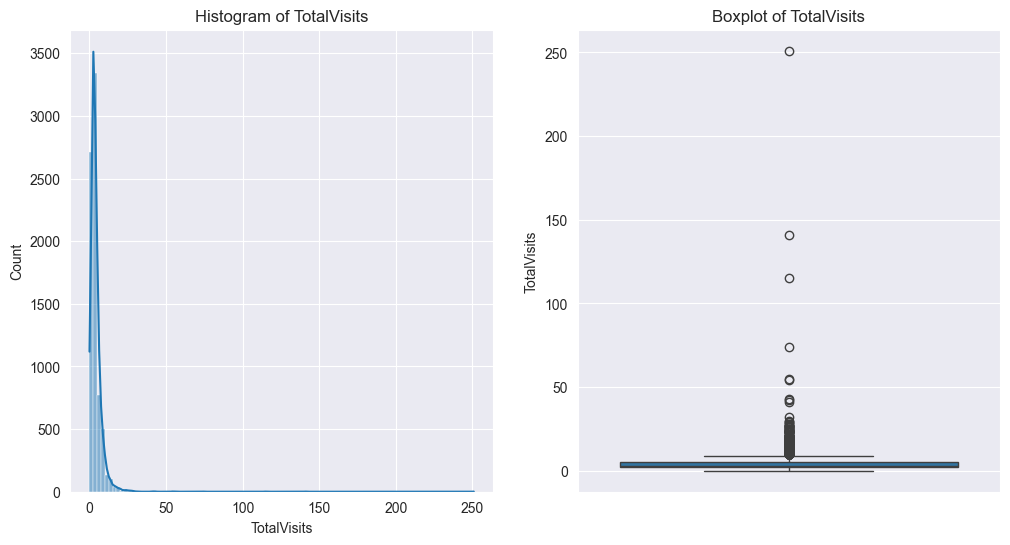

Chặn dưới và chặn trên của outlier là: -2.50 -> 9.50
Số lượng điểm dữ liệu được xem là outliers theo IQR là 467
Xử lý trên cột Total Time Spent on Website


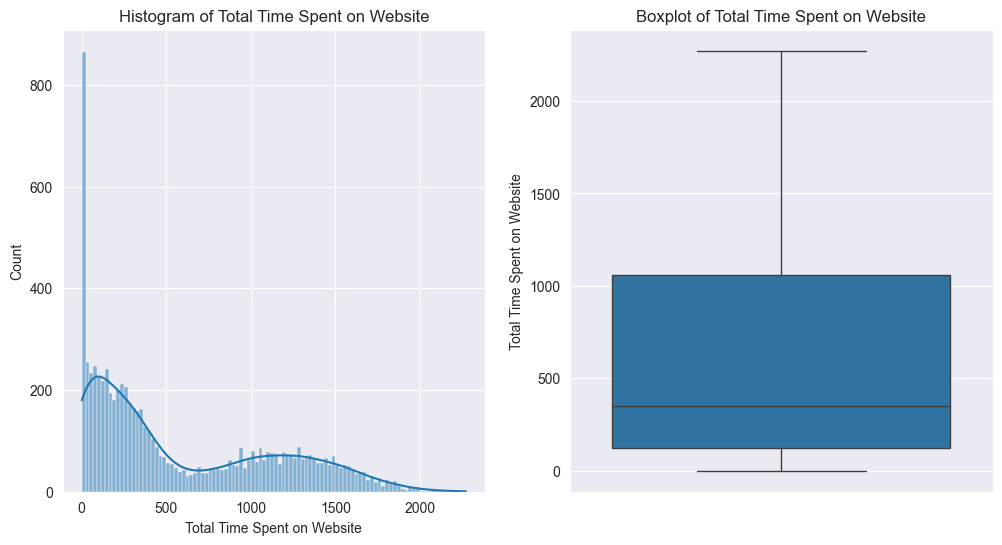

Chặn dưới và chặn trên của outlier là: -1277.50 -> 2462.50
Số lượng điểm dữ liệu được xem là outliers theo IQR là 0
Xử lý trên cột Page Views Per Visit


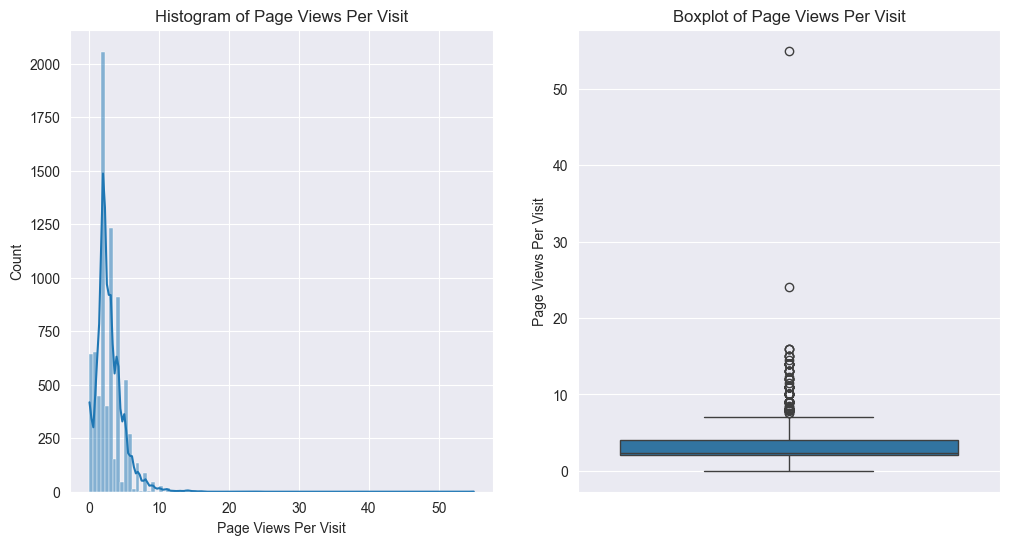

Chặn dưới và chặn trên của outlier là: -1.00 -> 7.00
Số lượng điểm dữ liệu được xem là outliers theo IQR là 211


In [ ]:
# Thực nghiệm trên từng cột
for column in numeric_columns:
    print(f"Xử lý trên cột {column}")
    plot_data_numeric(df, column)
    df, _, _ = detect_process_outliers(df, column)
    print("================================")


**Nhận xét**:
- **Cột TotalVisits**: có biểu đồ histogram bị lệch hoàn toàn về phía bên trái, các giá trị outlier trải dều về phía bên phải với khá ít dữ liệu (467 mẫu bị outlier) với cận dưới và trên lần lượt là -2.5 và 9.5.
- **Cột Total Time Spent on Website**: có biểu đồ histogram trải đều từ trái sang phải và không có outlier trong khoảng -1277.50 -> 2462.50.
- **Cột Page Views Per Visit**: có biểu đồ cũng có xu hướng lệch về phía bên trái với cận dưới và trên là -1 và 7 và có khoảng 211 điểm dữ liệu outliers.

Xử lý trên cột TotalVisits


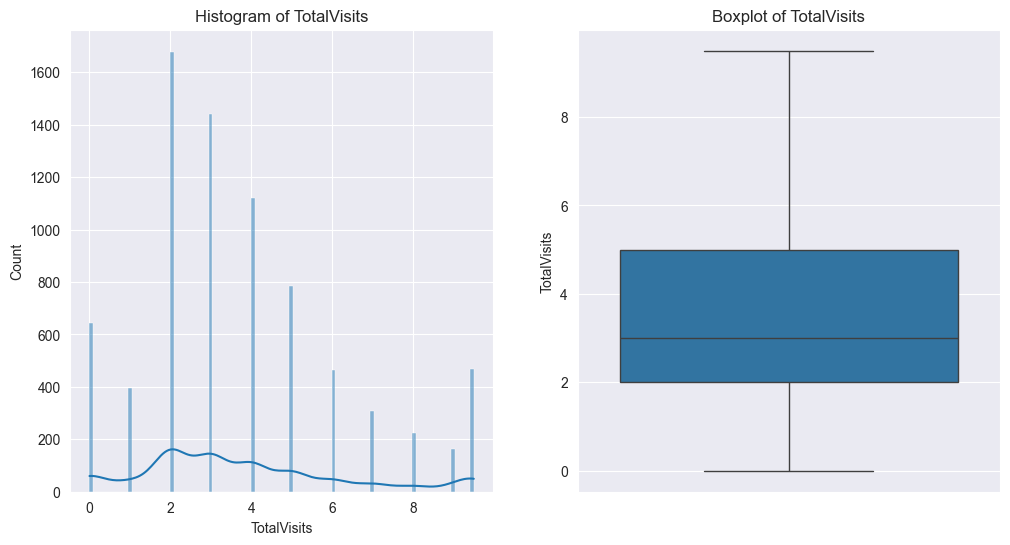

Xử lý trên cột Total Time Spent on Website


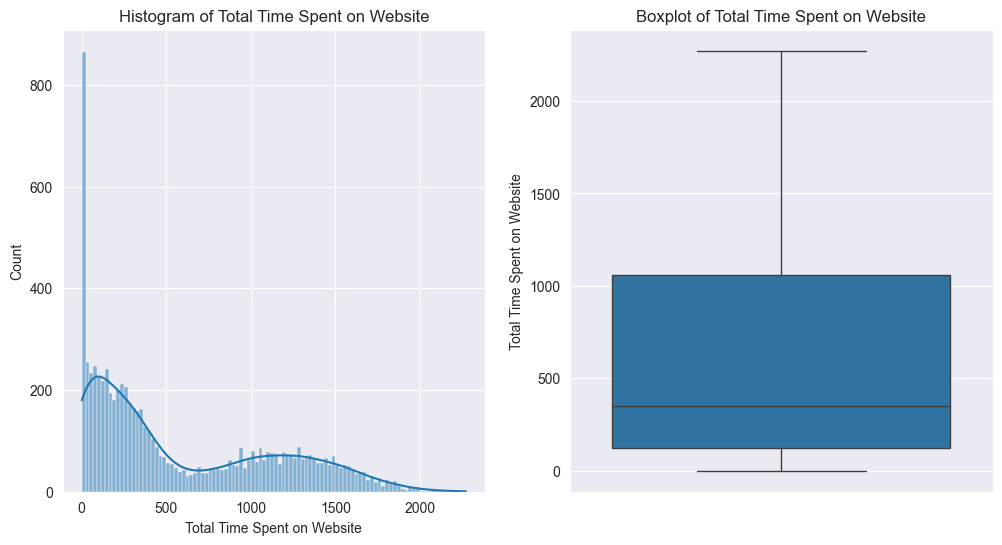

Xử lý trên cột Page Views Per Visit


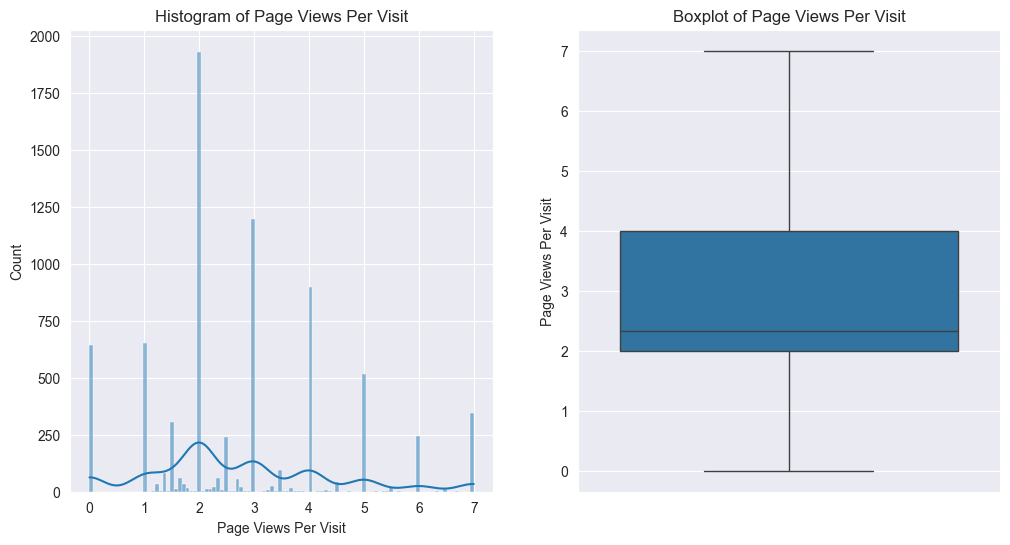

In [ ]:
# Kiểm tra biểu đồ các cột sau khi đã xử lý
for column in numeric_columns:
    print(f"Xử lý trên cột {column}")
    plot_data_numeric(df, column)


**Nhật xét**: Sau khi clipping dữ liệu outlier về vị trí cực tiểu hoặc cực đại thì phân bố dữ liệu trong histogram được trải đều và không còn outlier tồn tại theo IQR method.

## Outlier cho dữ liệu category

### Hàm bổ trợ

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def show_summary_and_plot_category(df: pd.DataFrame, name_column: str, outlier_threshold_pct: float = 1.0):
    """
    Hiển thị bảng tóm tắt và biểu đồ tần số cho biến phân loại.
    Hiển thị tất cả các danh mục (không gộp), tự động xoay nhãn và điều chỉnh kích thước.

    Parameters
    ----------
    df : pd.DataFrame
    name_column : str
        Tên cột cần phân tích
    outlier_threshold_pct : float, default=1.0
        Ngưỡng % để đánh dấu outlier (giá trị dưới ngưỡng này được tô màu khác trên bảng)
    """
    # Tính tần số và %
    value_counts = df[name_column].value_counts(dropna=False)
    total = value_counts.sum()
    summary = pd.DataFrame({
        'Category': value_counts.index,
        'Count': value_counts.values,
        'Percent (%)': (value_counts.values / total * 100).round(2)
    })
    summary['Outlier'] = summary['Percent (%)'] < outlier_threshold_pct

    n_categories = len(summary)

    # Điều chỉnh kích thước figure theo số lượng danh mục
    fig_height = max(6, n_categories * 0.3)
    fig, axes = plt.subplots(1, 2, figsize=(14, fig_height),
                             gridspec_kw={'width_ratios': [1.2, 2]})

    # 1. Bảng bên trái
    axes[0].axis('off')
    table = axes[0].table(cellText=summary[['Category', 'Count', 'Percent (%)']].values,
                          colLabels=['Category', 'Count', 'Percent (%)'],
                          cellLoc='left', loc='center')
    # Tô màu header và outlier
    for (i, j), cell in table.get_celld().items():
        if i == 0:  # header
            cell.set_facecolor('#40466e')
            cell.set_text_props(weight='bold', color='white')
        elif i-1 < len(summary) and summary.iloc[i-1]['Outlier']:
            cell.set_facecolor('#ffcccc')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    axes[0].set_title(f"{name_column} – Summary (outlier < {outlier_threshold_pct}%)", fontweight='bold', pad=50)

    # 2. Biểu đồ bên phải
    ax = axes[1]
    # Lấy thứ tự theo tần số giảm dần
    order = summary['Category'].values
    sns.countplot(data=df, x=name_column, order=order,
              hue=name_column, legend=False,
              palette='viridis', ax=ax)
    ax.set_title(f"Count Plot of {name_column} (all categories)", fontweight='bold')
    ax.set_xlabel(name_column)
    ax.set_ylabel('Count')

    # Xoay nhãn trục x để tránh chồng lấn
    rotation_angle = 90 if n_categories > 15 else 45
    ax.tick_params(axis='x', rotation=rotation_angle, labelsize=8)

    # Thêm số liệu trên cột
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=7, padding=2)

    # Điều chỉnh lề dưới để chứa nhãn dài
    plt.subplots_adjust(bottom=0.2 if rotation_angle == 45 else 0.3)
    plt.tight_layout()
    plt.show()

    # In danh sách outlier
    outliers = summary[summary['Outlier']]
    if not outliers.empty:
        print("\n⚠️ Các giá trị có thể là outlier (tần suất < {}%):".format(outlier_threshold_pct))
        print(outliers[['Category', 'Count', 'Percent (%)']].to_string(index=False))
    else:
        print(f"\n✅ Không phát hiện outlier nào dưới {outlier_threshold_pct}%.")


### Tìm kiếm outliers

In [ ]:
category_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Các cột category trong dataset: {category_columns}")


Các cột category trong dataset: ['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Specialization', 'What is your current occupation', 'Tags', 'Lead Profile', 'City', 'A free copy of Mastering The Interview', 'Last Notable Activity']


Cột Lead Origin


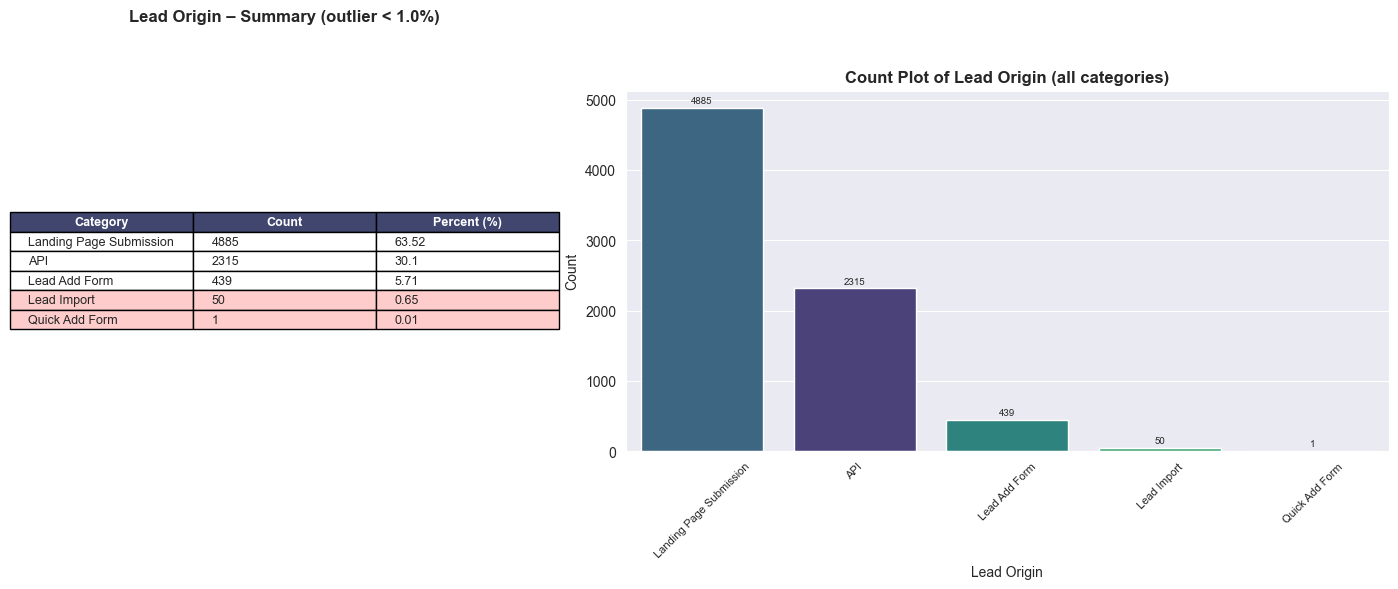


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
      Category  Count  Percent (%)
   Lead Import     50         0.65
Quick Add Form      1         0.01

Cột Lead Source


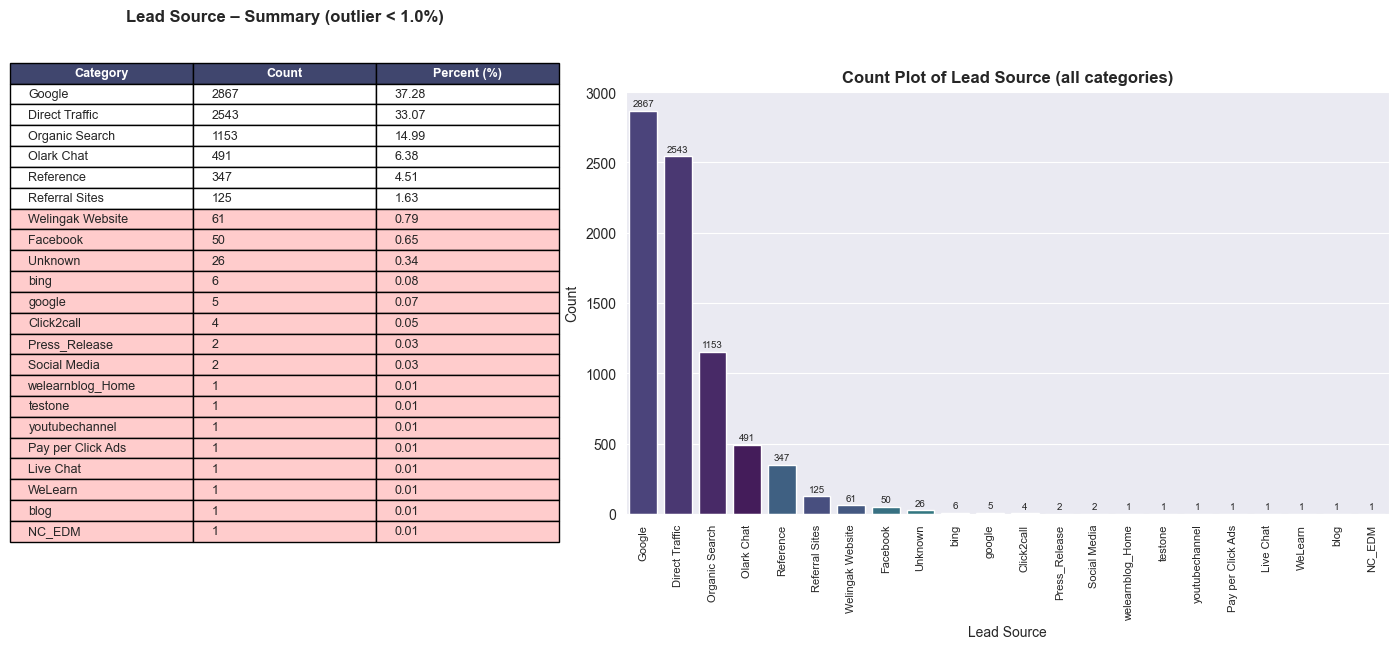


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
         Category  Count  Percent (%)
 Welingak Website     61         0.79
         Facebook     50         0.65
          Unknown     26         0.34
             bing      6         0.08
           google      5         0.07
       Click2call      4         0.05
    Press_Release      2         0.03
     Social Media      2         0.03
 welearnblog_Home      1         0.01
          testone      1         0.01
   youtubechannel      1         0.01
Pay per Click Ads      1         0.01
        Live Chat      1         0.01
          WeLearn      1         0.01
             blog      1         0.01
           NC_EDM      1         0.01

Cột Do Not Email


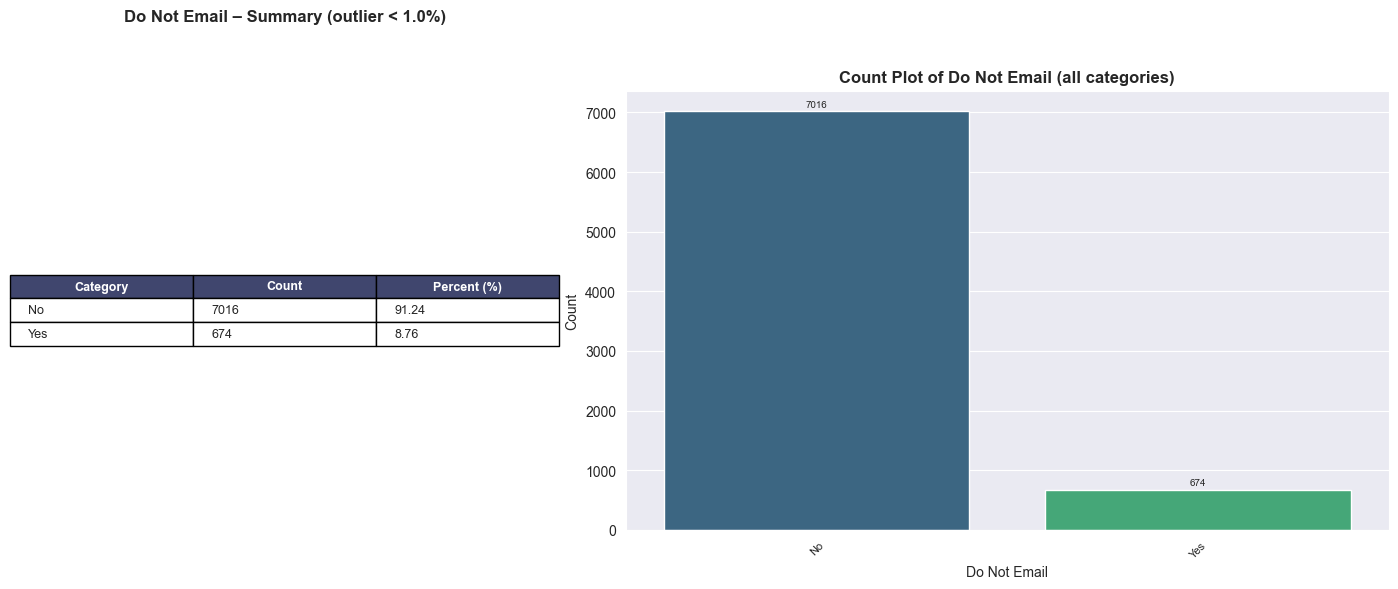


✅ Không phát hiện outlier nào dưới 1.0%.

Cột Do Not Call


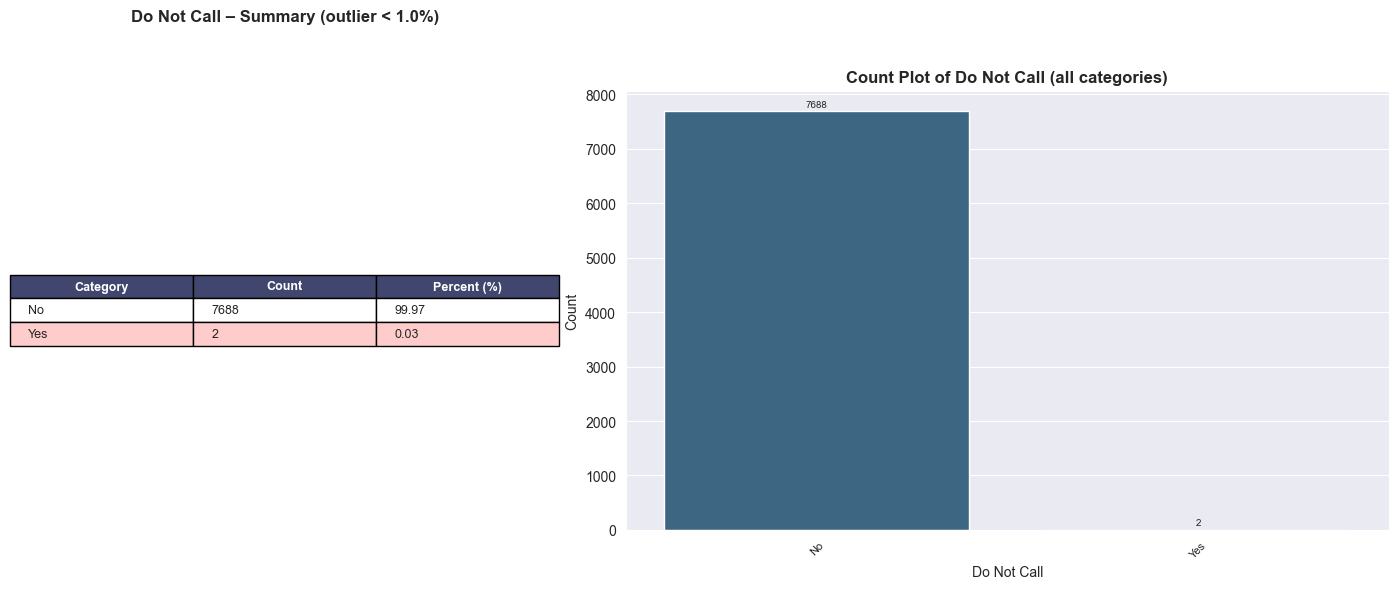


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
Category  Count  Percent (%)
     Yes      2         0.03

Cột Last Activity


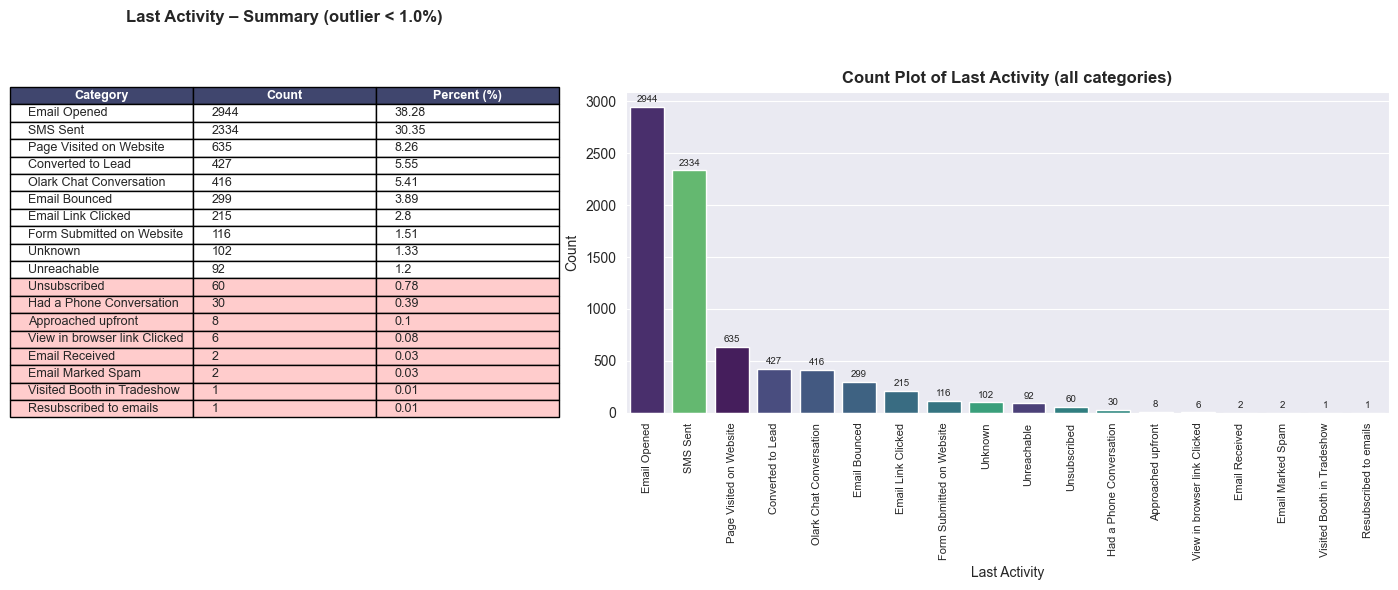


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
                    Category  Count  Percent (%)
                Unsubscribed     60         0.78
    Had a Phone Conversation     30         0.39
          Approached upfront      8         0.10
View in browser link Clicked      6         0.08
              Email Received      2         0.03
           Email Marked Spam      2         0.03
  Visited Booth in Tradeshow      1         0.01
      Resubscribed to emails      1         0.01

Cột Specialization


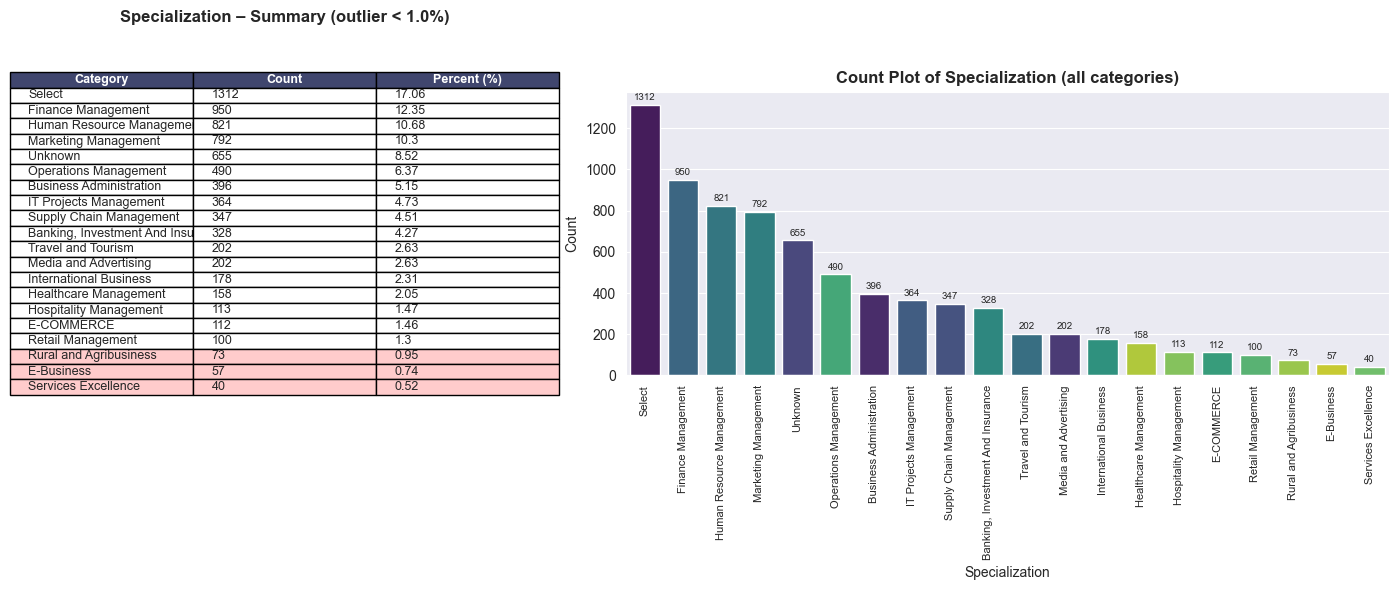


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
              Category  Count  Percent (%)
Rural and Agribusiness     73         0.95
            E-Business     57         0.74
   Services Excellence     40         0.52

Cột What is your current occupation


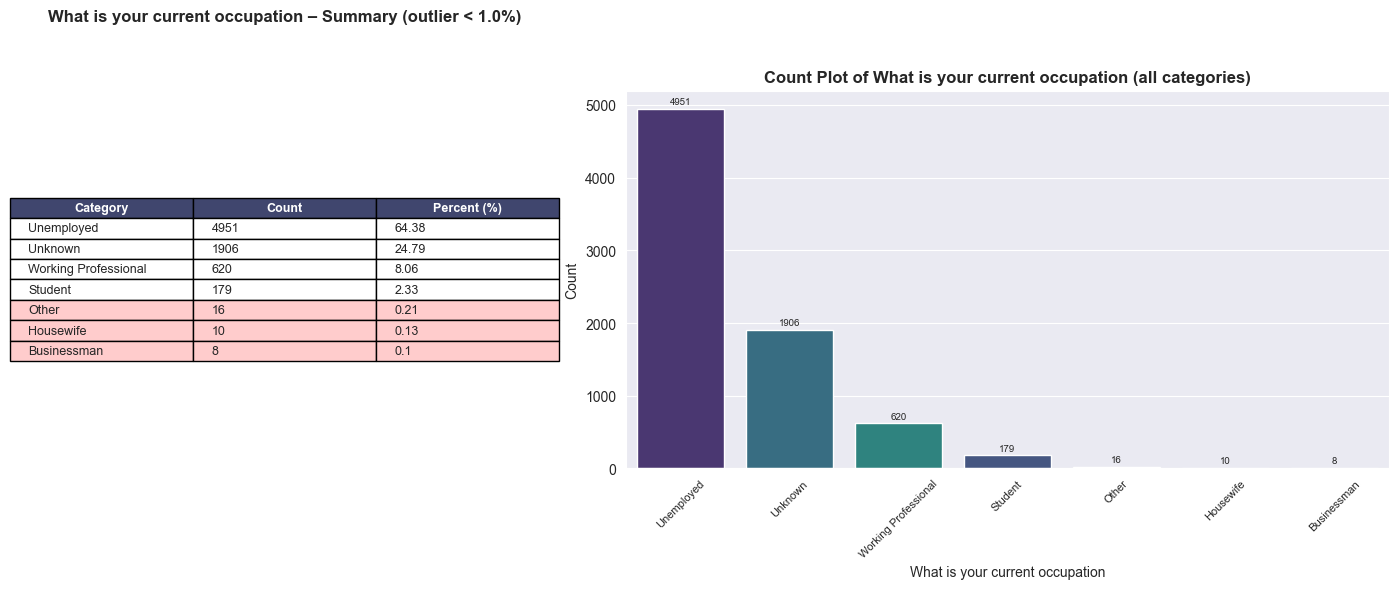


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
   Category  Count  Percent (%)
      Other     16         0.21
  Housewife     10         0.13
Businessman      8         0.10

Cột Tags


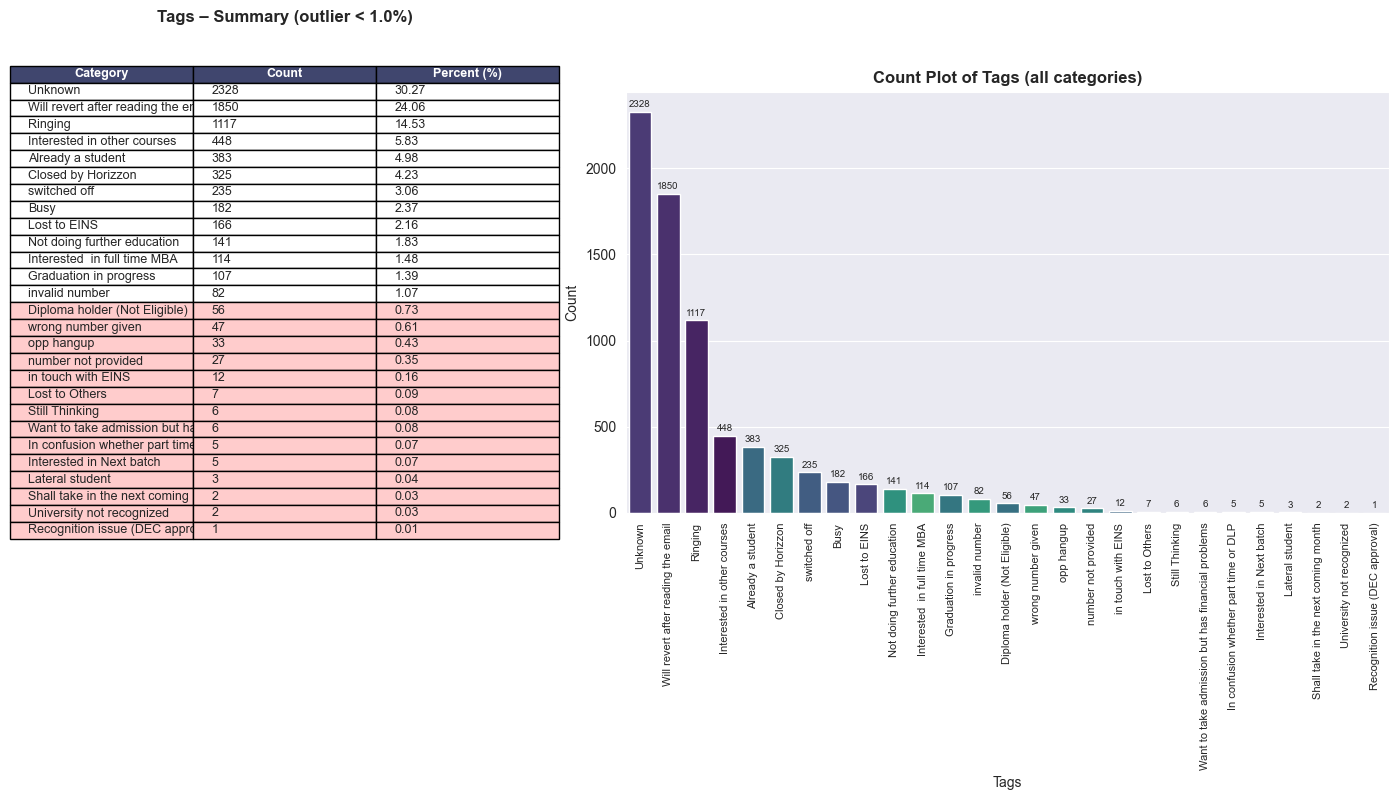


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
                                         Category  Count  Percent (%)
                    Diploma holder (Not Eligible)     56         0.73
                               wrong number given     47         0.61
                                       opp hangup     33         0.43
                              number not provided     27         0.35
                               in touch with EINS     12         0.16
                                   Lost to Others      7         0.09
                                   Still Thinking      6         0.08
Want to take admission but has financial problems      6         0.08
            In confusion whether part time or DLP      5         0.07
                         Interested in Next batch      5         0.07
                                  Lateral student      3         0.04
              Shall take in the next coming month      2         0.03
                        University no

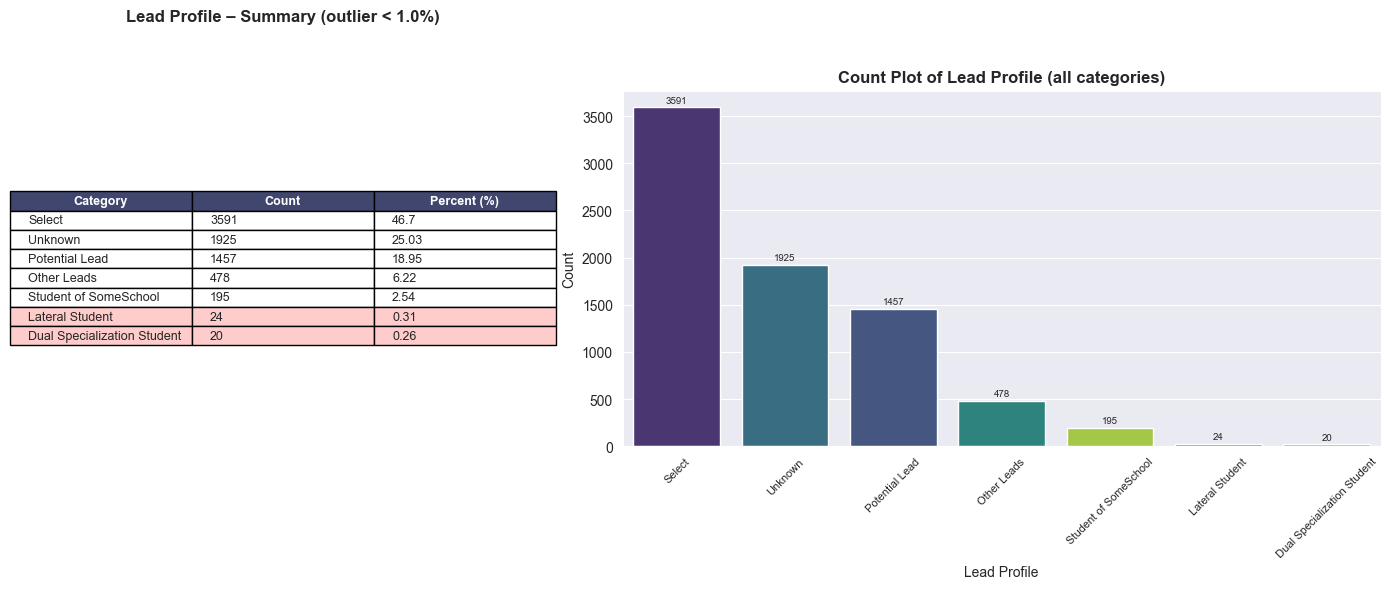


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
                   Category  Count  Percent (%)
            Lateral Student     24         0.31
Dual Specialization Student     20         0.26

Cột City


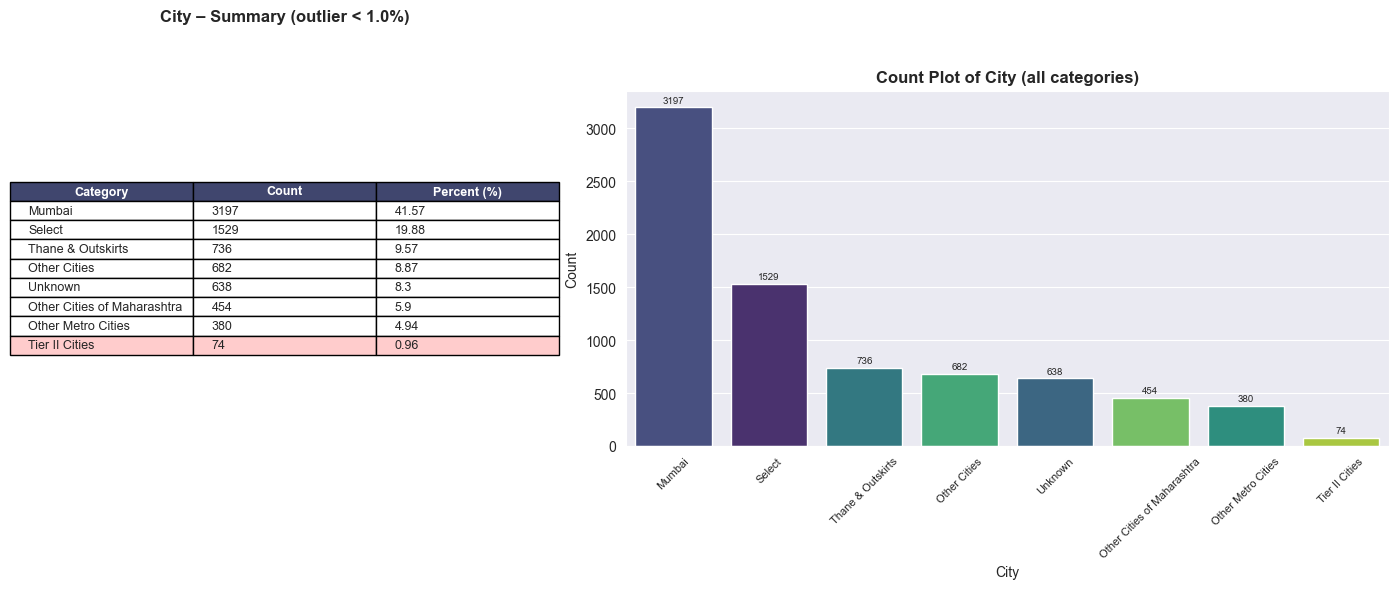


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
      Category  Count  Percent (%)
Tier II Cities     74         0.96

Cột A free copy of Mastering The Interview


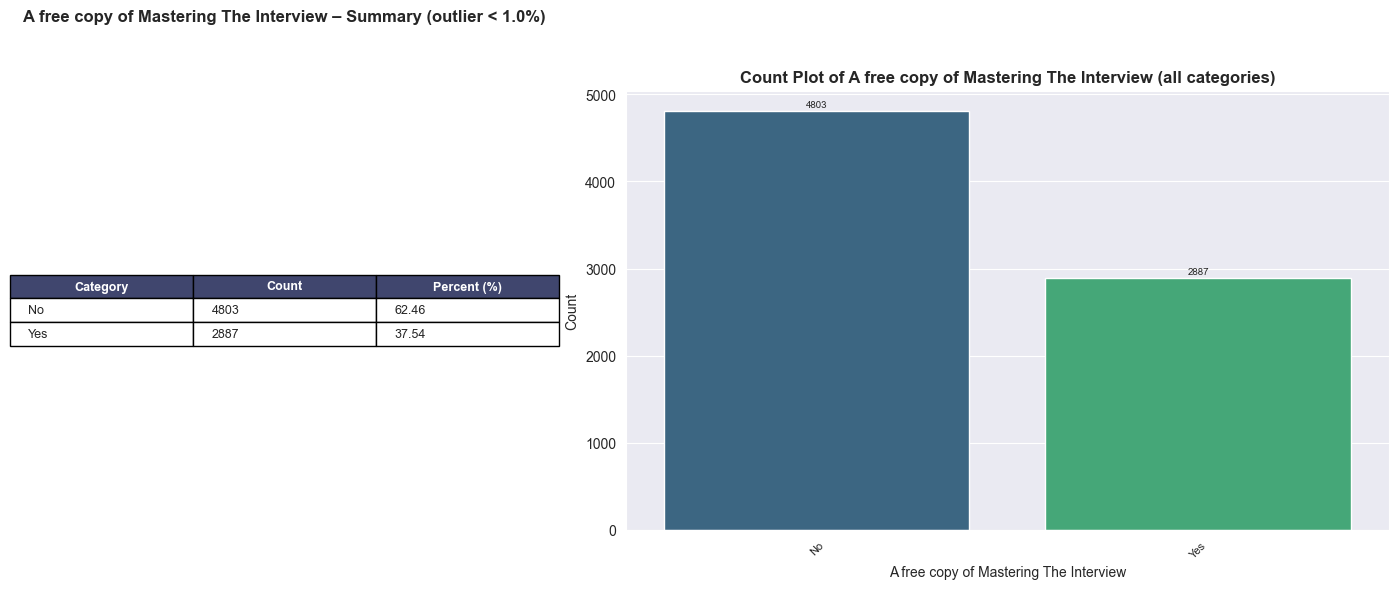


✅ Không phát hiện outlier nào dưới 1.0%.

Cột Last Notable Activity


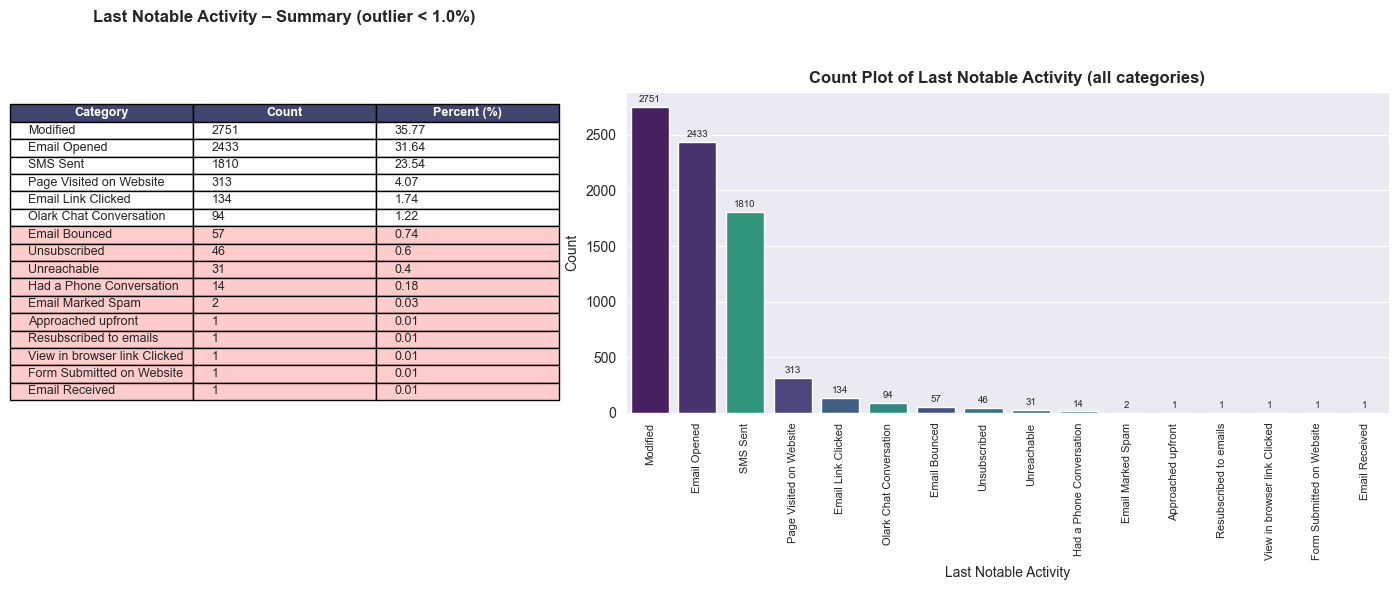


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
                    Category  Count  Percent (%)
               Email Bounced     57         0.74
                Unsubscribed     46         0.60
                 Unreachable     31         0.40
    Had a Phone Conversation     14         0.18
           Email Marked Spam      2         0.03
          Approached upfront      1         0.01
      Resubscribed to emails      1         0.01
View in browser link Clicked      1         0.01
   Form Submitted on Website      1         0.01
              Email Received      1         0.01



In [ ]:
for column in category_columns:
    print(f"Cột {column}")
    show_summary_and_plot_category(df, column)
    print()


**Nhận xét**:
- Cột **Lead Origin**: category Quick Add Form và Lead Import có số lượng mẫu rất nhỏ < 1% được xem là outlier --> Nên gộp 2 cái này thành category mới là Other.
- Cột **Lead Source** gộp theo nguồn:
    - "Google" + "google" --> "Google"
    - "Olark Chat" + "Live Chat" --> "Chat"
    - "Referral Sites" + "Reference" --> "Referral"
    -  Những phần còn lại cái nào < 1% thì gộp lại thành Other, lớn hơn thì giữ lại.
- Cột **Specialization** gộp theo nghiệp vụ:
    - "Finance Management" + "Banking, Investment And Insurances" --> "Finance & Banking"
    - "Marketing Management" + "Media and Advertising" --> "Marketing & Advertising"
    - "E-COMMERCE" + "E-Business" --> "E‑Commerce"
    - "Hospitality Management" + "Travel and Tourism" --> "Hospitality & Tourism"
    - "Rural and Agribusiness" và "Services Excellence" đều nhỏ hơn 1% nên gộp thành Other.
    - Unknown + Select --> Not Specified.
    - Các category > 1% thì giữ lại.
- Cột **Last Activity**:
    - Các hành động khác nhau sẽ có một ý nghĩa khác biệt đối với lead --> không cần gộp những category > 1%.
    - Các category < 1% thì gộp thành Other.
- Cột **What is your current occupation**:
    - Các category > 1% thì giữ lại.
    - Dưới 1% thì gộp lại thành Other.
- Cột **Tags**: Ta sẽ gọi một số tag có liên quan như sau:
    - Still thinking, In confusion whether part time, Interested in Next batch, Want to take admission but in, Shall take in the next coming --> Will Revert (sẽ phản hồi lại sau).
    - wrong number given, number not provided, opp hangup --> invalid number
    - Lost to Others, in touch with EINS --> Lost to EINS
    - Diploma holder (Not Eligible), University not recognized, Recognition issue (DEC app) --> Not doing further education
    - Lateral student gộp vào Already a student.
    - Các tag còn lại > 1% thi giữ nguyên vì chúng mang ý nghĩa riêng.
- Cột **Lead Profile**:
    - Select + Unkown  --> Not Specified.
    - 'Lateral Student' + 'Dual Specialization Student' --> Other Students (Vì < 1%).
    - Các cột còn lại giữ nguyên.
- Cột **city**:
    - Select + Unkown  --> Not Specified.
    - Other Cities + Tier II Cities + Other Cities of Maharashtra --> Other Cities.
- Cột **Last Notable Activity**:
    - Các hành động khác nhau sẽ có một ý nghĩa khác biệt đối với lead --> không cần gộp những category > 1%.
    - Các category < 1% thì gộp thành Other.

### Thực nghiệm trên từng cột

In [ ]:
def map_categories(df, name_column, mapping, inplace=True, verbose=True):
    """
    Map categories in a column using a dictionary.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu

    name_column : str
        Tên cột cần mapping

    mapping : dict
        Dictionary dạng:
        {
            'old_value': 'new_value',
            ...
        }

    inplace : bool (default=True)
        True  -> cập nhật trực tiếp df
        False -> trả về copy

    verbose : bool (default=True)
        True -> in thông tin mapping

    Returns
    -------
    pandas.DataFrame
        DataFrame đã được mapping
    """

    # kiểm tra cột tồn tại
    if name_column not in df.columns:
        raise ValueError(f"Column '{name_column}' not found in DataFrame")

    # copy nếu cần
    if not inplace:
        df = df.copy()

    # lưu trước khi mapping
    before_counts = df[name_column].value_counts()

    # mapping
    df[name_column] = df[name_column].replace(mapping)

    # logging
    if verbose:

        after_counts = df[name_column].value_counts()

        changed_keys = set(mapping.keys()) & set(before_counts.index)

        print(f"\nColumn: {name_column}")
        print(f"Mapped categories: {len(changed_keys)}")

        for key in changed_keys:
            old_count = before_counts.get(key, 0)
            new_value = mapping[key]
            print(f"{key} ({old_count}) → {new_value}")

    return df


In [ ]:
# Mapping
lead_origin_mapping = {
    "Quick Add Form": "Other",
    "Lead Import": "Other"
}

lead_source_mapping = {
    "google": "Google",
    "Olark Chat": "Chat",
    "Live Chat": "Chat",
    "Referral Sites": "Referral",
    "Reference": "Referral",
    'Welingak Website': 'Other',
    'Facebook': 'Other',
    'Unknown': 'Other',
    'blog': 'Other',
    'Pay per Click Ads': 'Other',
    'bing': 'Other',
    'Social Media': 'Other',
    'WeLearn': 'Other',
    'Click2call': 'Other',
    'welearnblog_Home': 'Other',
    'youtubechannel': 'Other',
    'testone': 'Other',
    'Press_Release': 'Other',
    'NC_EDM': 'Other'
}

last_activity_mapping = {
    "Unsubscribed": "Other",
    "Had a Phone Conversation": "Other",
    "Approached upfront": "Other",
    "View in browser link Clicked": "Other",
    "Email Received": "Other",
    "Email Marked Spam": "Other",
    "Visited Booth in Tradeshow": "Other",
    "Resubscribed to emails": "Other"
}

specialization_mapping = {
    "Finance Management": "Finance & Banking",
    "Banking, Investment And Insurances": "Finance & Banking",
    "Marketing Management": "Marketing & Advertising",
    "Media and Advertising": "Marketing & Advertising",
    "E-COMMERCE": "E-Commerce",
    "E-Business": "E-Commerce",
    "Hospitality Management": "Hospitality & Tourism",
    "Travel and Tourism": "Hospitality & Tourism",
    "Rural and Agribusiness": "Other",
    "Services Excellence": "Other",
    "Select": "Not Specified",
    "Unknown": "Not Specified",
}

occupation_mapping = {
    "Unknown": "Not Specified",
    "Housewife": "Other",
    "Businessman": "Other"
}

tags_mapping = {
    "Still Thinking": "Will Revert",
    "In confusion whether part time or DLP": "Will Revert",
    "Interested in Next batch": "Will Revert",
    "Want to take admission but has financial problems": "Will Revert",
    "Shall take in the next coming month": "Will Revert",
    "wrong number given": "invalid number",
    "number not provided": "invalid number",
    "opp hangup": "invalid number",
    "Lost to Others": "Lost to EINS",
    "in touch with EINS": "Lost to EINS",
    "Diploma holder (Not Eligible)": "Not doing further education",
    "University not recognized": "Not doing further education",
    "Recognition issue (DEC approval)": "Not doing further education",
    "Lateral student": "Already a student",
    "Unknown": "Not Specified"
}

lead_profile_mapping = {
    "Select": "Not Specified",
    "Unknown": "Not Specified",
    "Lateral Student": "Other Students",
    "Dual Specialization Student": "Other Students"
}

city_mapping = {
    "Select": "Not Specified",
    "Unknown": "Not Specified",
    "Other Cities": "Other Cities",
    "Tier II Cities": "Other Cities",
    "Other Cities of Maharashtra": "Other Cities",
}

last_notable_activity_mapping = {
    "Email Bounced": "Other",
    "Email Marked Spam": "Other",
    "Email Received": "Other",
    "Form Submitted on Website": "Other",
    "Had a Phone Conversation": "Other",
    "View in browser link Clicked": "Other",
    "Approached upfront": "Other",
    "Resubscribed to emails": "Other",
    "Unsubscribed": "Other",
    "Unreachable": "Other",
}


In [ ]:
df['Tags'].unique()


array(['Interested in other courses', 'Ringing',
       'Will revert after reading the email', 'Unknown', 'Lost to EINS',
       'In confusion whether part time or DLP', 'Busy', 'switched off',
       'in touch with EINS', 'Already a student',
       'Diploma holder (Not Eligible)', 'Graduation in progress',
       'Closed by Horizzon', 'number not provided', 'opp hangup',
       'Not doing further education', 'invalid number',
       'wrong number given', 'Interested  in full time MBA',
       'Still Thinking', 'Lost to Others',
       'Shall take in the next coming month', 'Lateral student',
       'Interested in Next batch', 'Recognition issue (DEC approval)',
       'Want to take admission but has financial problems',
       'University not recognized'], dtype=object)

In [ ]:
cols_to_remove = ['Do Not Email', 'Do Not Call', 'A free copy of Mastering The Interview']
category_columns = [col for col in category_columns if col not in cols_to_remove]
mapping = [lead_origin_mapping, lead_source_mapping, last_activity_mapping, specialization_mapping, occupation_mapping, tags_mapping, lead_profile_mapping, city_mapping, last_notable_activity_mapping]


In [ ]:
for i in range(len(category_columns)):
    df = map_categories(df, category_columns[i], mapping[i])



Column: Lead Origin
Mapped categories: 2
Quick Add Form (1) → Other
Lead Import (50) → Other

Column: Lead Source
Mapped categories: 19
Social Media (2) → Other
Welingak Website (61) → Other
google (5) → Google
Press_Release (2) → Other
Reference (347) → Referral
Unknown (26) → Other
blog (1) → Other
Facebook (50) → Other
Pay per Click Ads (1) → Other
welearnblog_Home (1) → Other
Olark Chat (491) → Chat
bing (6) → Other
Click2call (4) → Other
testone (1) → Other
Referral Sites (125) → Referral
WeLearn (1) → Other
youtubechannel (1) → Other
NC_EDM (1) → Other
Live Chat (1) → Chat

Column: Last Activity
Mapped categories: 8
Visited Booth in Tradeshow (1) → Other
Had a Phone Conversation (30) → Other
Approached upfront (8) → Other
View in browser link Clicked (6) → Other
Resubscribed to emails (1) → Other
Email Marked Spam (2) → Other
Unsubscribed (60) → Other
Email Received (2) → Other

Column: Specialization
Mapped categories: 11
Unknown (655) → Not Specified
E-Business (57) → E-Commer

Cột Lead Origin


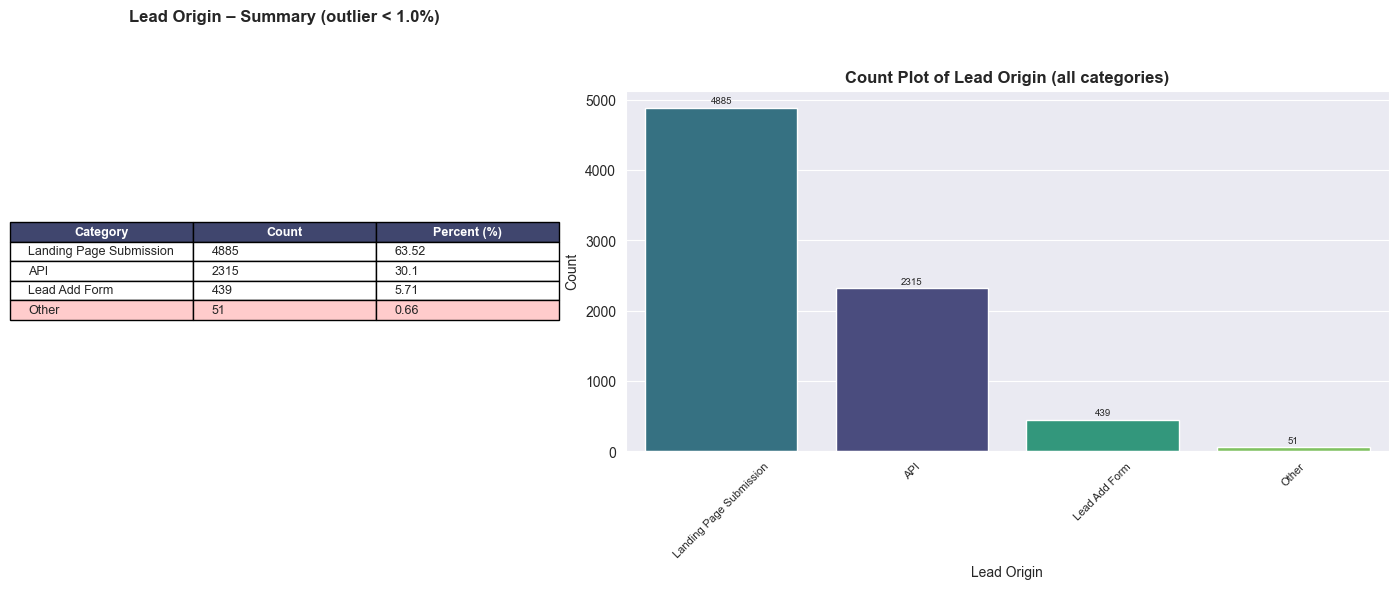


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
Category  Count  Percent (%)
   Other     51         0.66

Cột Lead Source


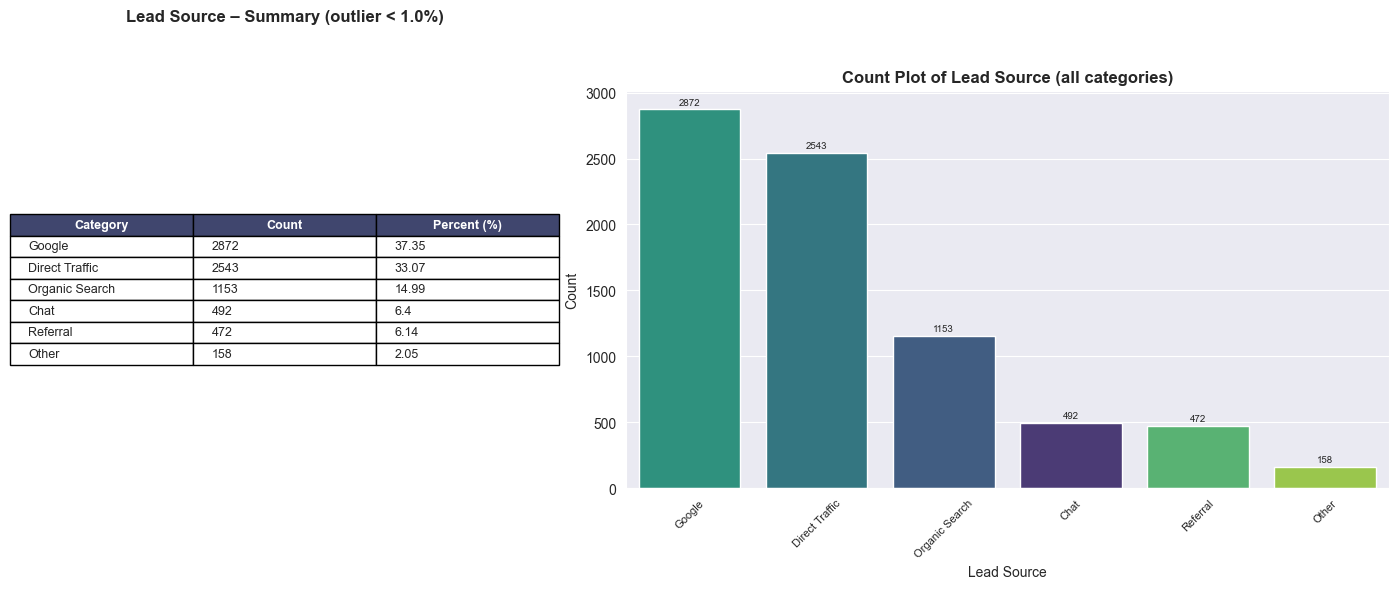


✅ Không phát hiện outlier nào dưới 1.0%.

Cột Last Activity


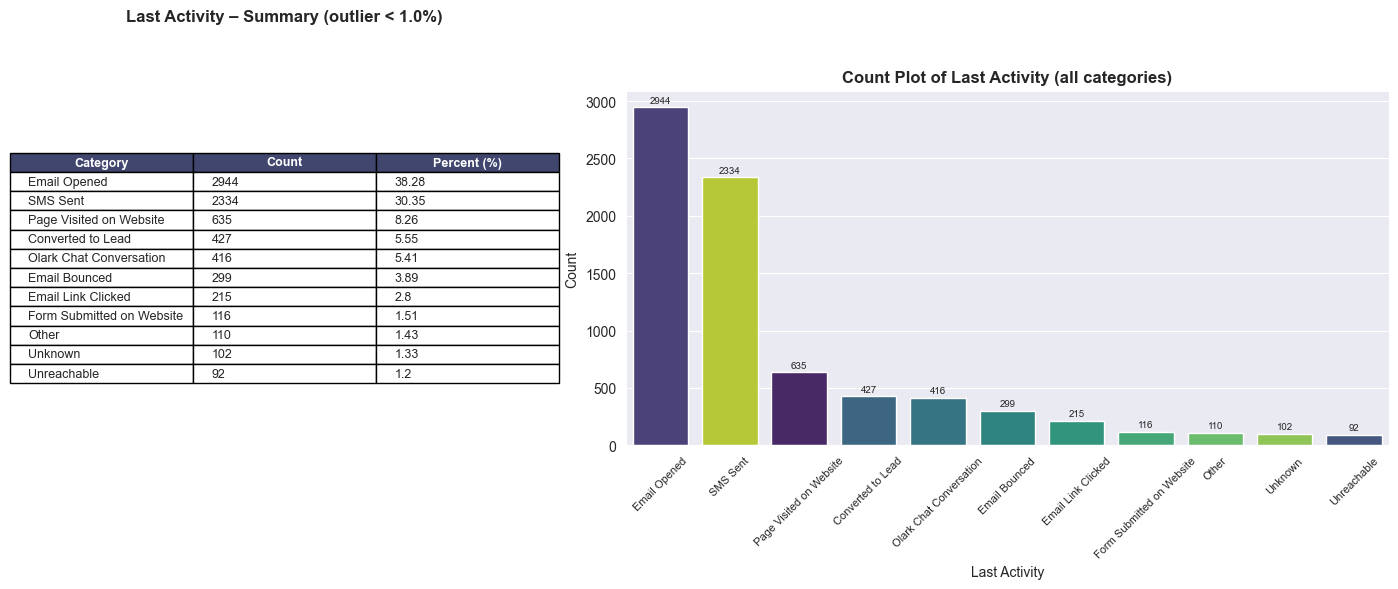


✅ Không phát hiện outlier nào dưới 1.0%.

Cột Specialization


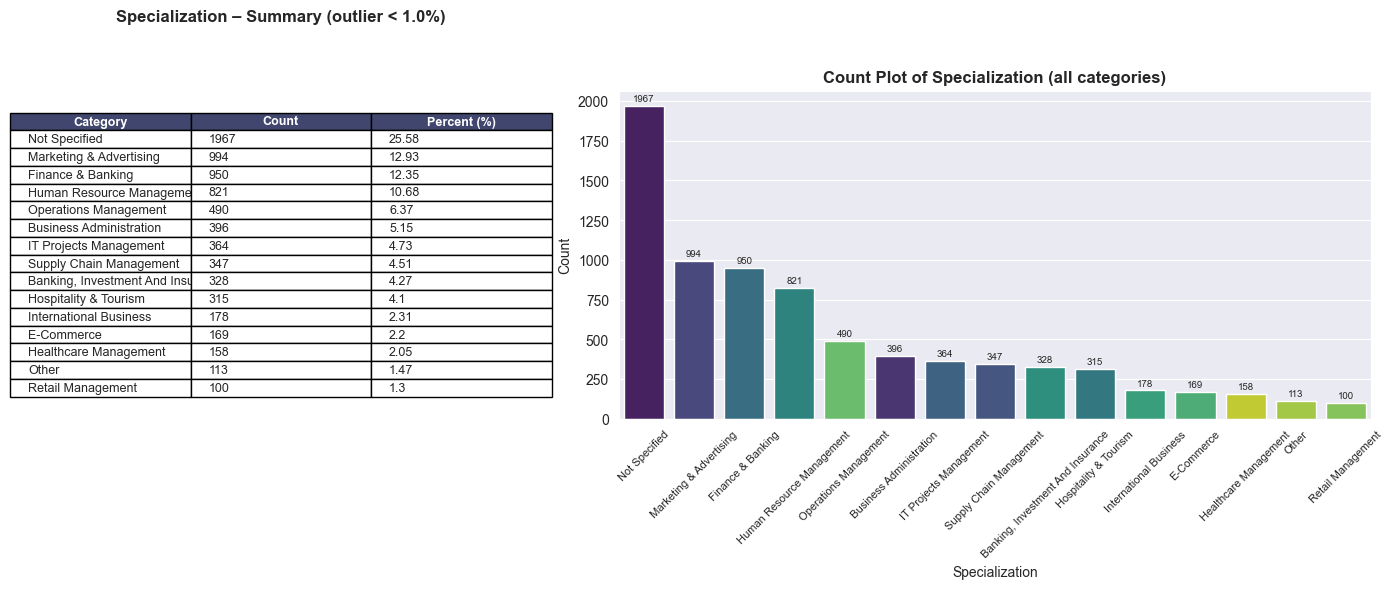


✅ Không phát hiện outlier nào dưới 1.0%.

Cột What is your current occupation


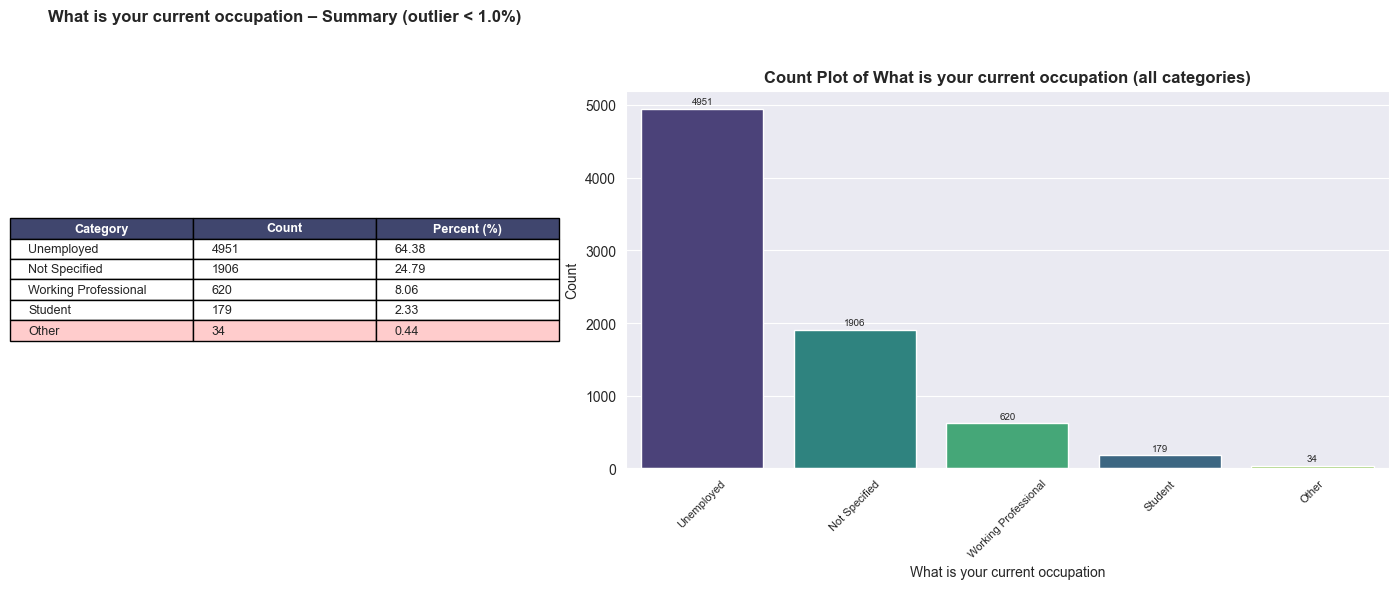


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
Category  Count  Percent (%)
   Other     34         0.44

Cột Tags


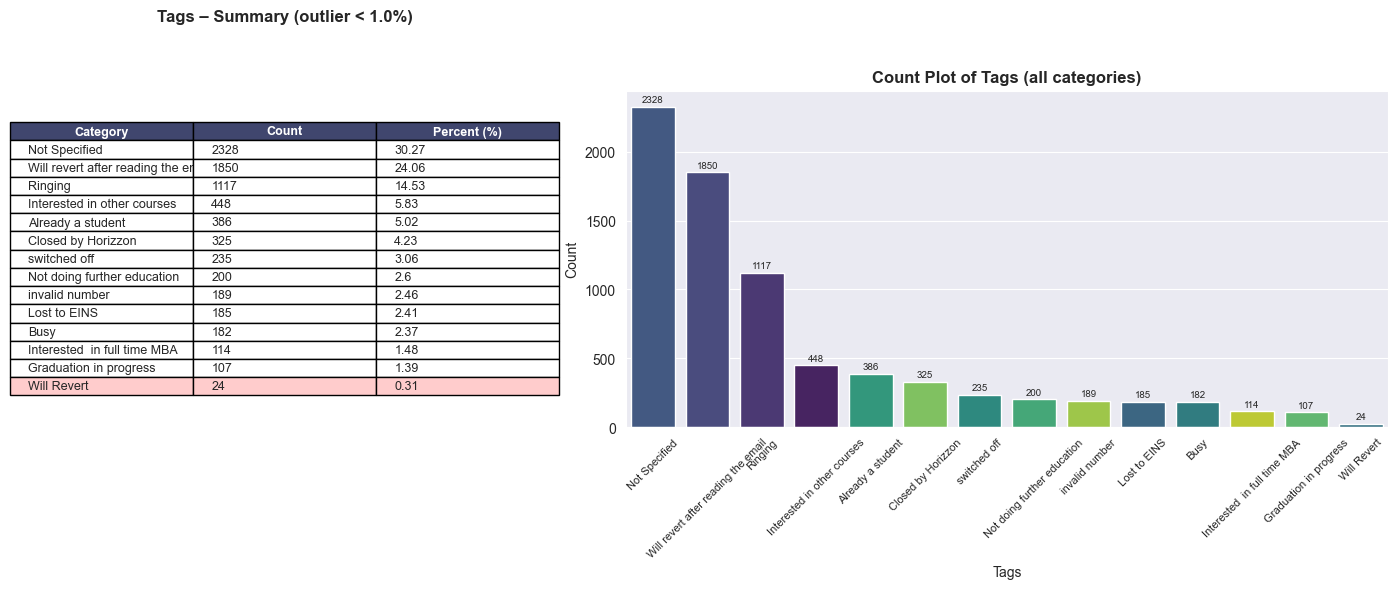


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
   Category  Count  Percent (%)
Will Revert     24         0.31

Cột Lead Profile


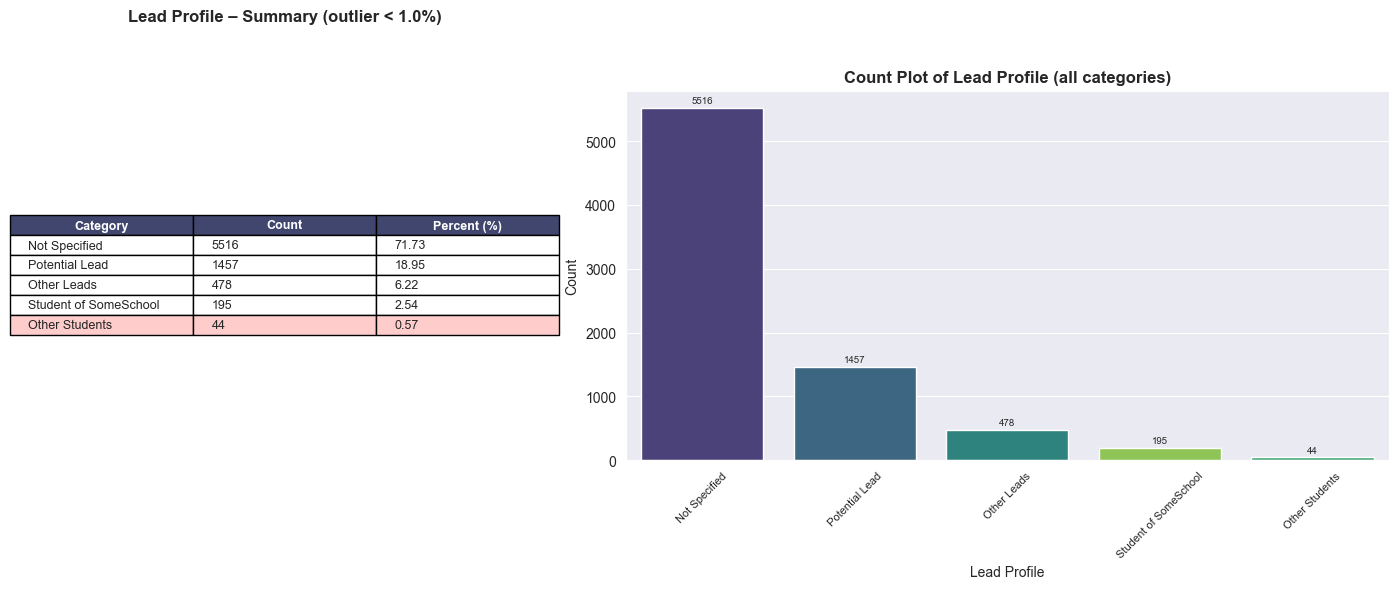


⚠️ Các giá trị có thể là outlier (tần suất < 1.0%):
      Category  Count  Percent (%)
Other Students     44         0.57

Cột City


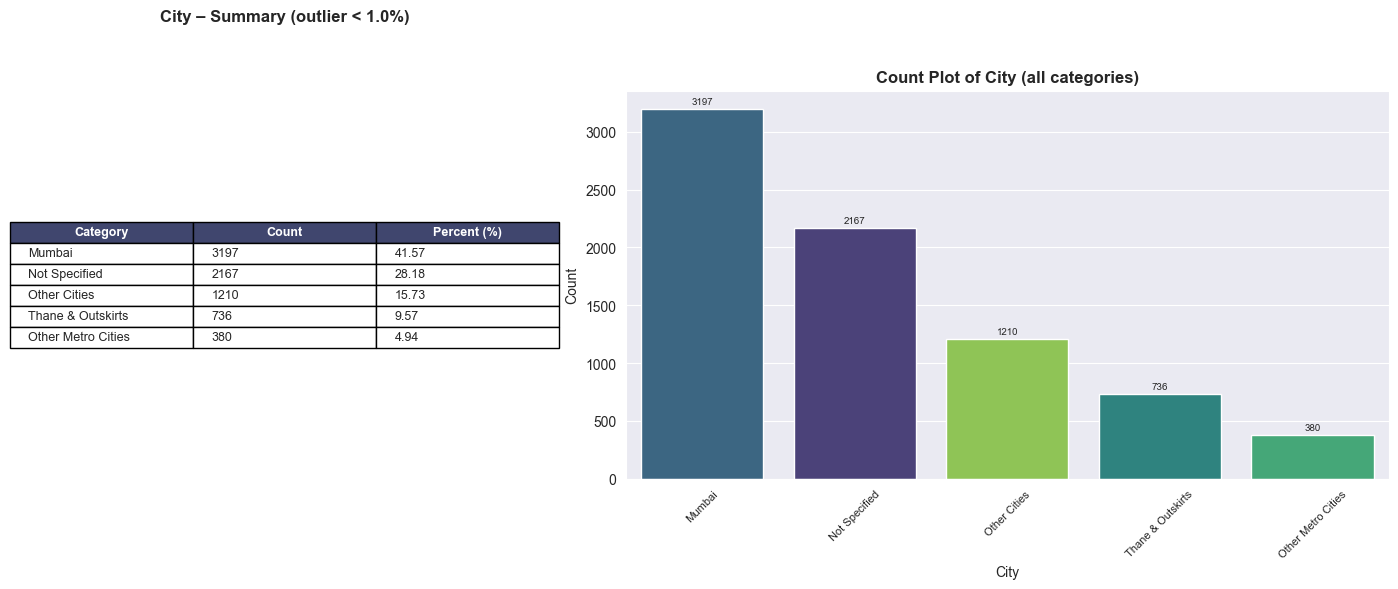


✅ Không phát hiện outlier nào dưới 1.0%.

Cột Last Notable Activity


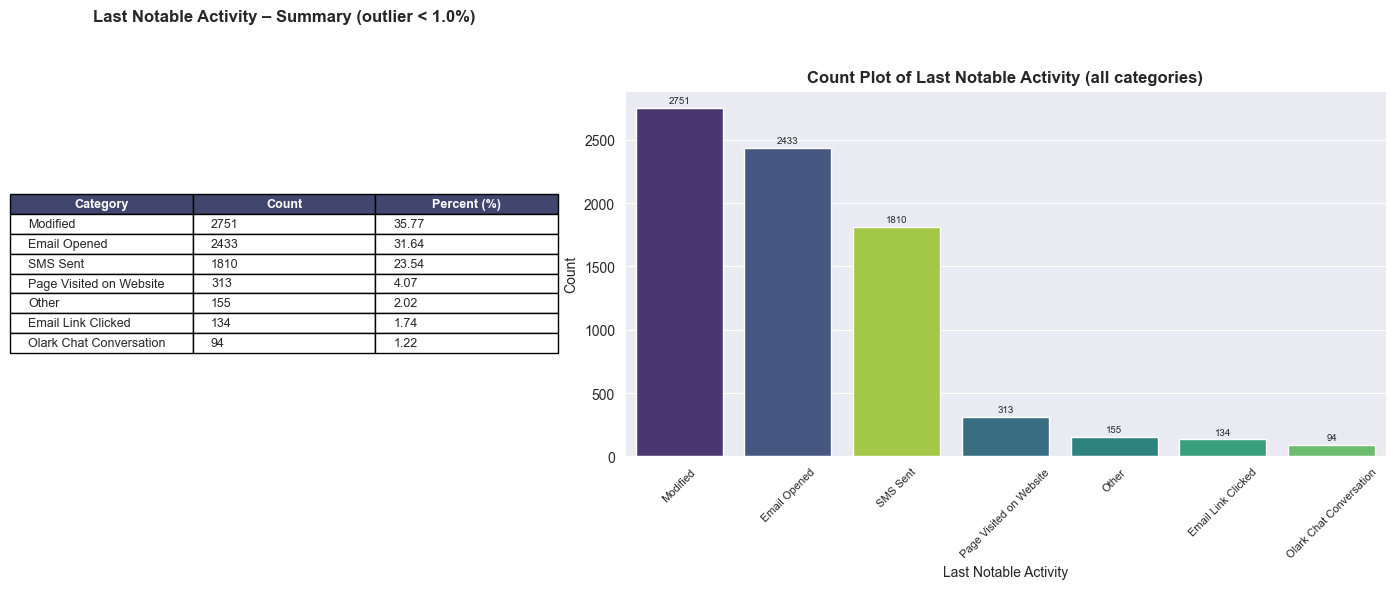


✅ Không phát hiện outlier nào dưới 1.0%.



In [ ]:
for column in category_columns:
    print(f"Cột {column}")
    show_summary_and_plot_category(df, column)
    print()


**Nhận xét**: Các cột hiện tại có rất ít category < 1% hoặc nếu có thì nó là những giá trị đã gộp với nhau nên không cần xử lý.

In [ ]:
df.to_csv("Processed_Leads.csv", index=False, encoding='utf-8-sig')
